# Stage 7 — Feature Fusion

Wav2Vec2 embeddings (768-d) + handcrafted acoustic features (118-d) → fusion head.

**Is fusion useful?** Run the controlled A/B experiment:

```bash
python scripts/experiment_fusion_ab.py
```

Results: `outputs/fusion_ab_results.json`

In [8]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))
from config import OUTPUTS_DIR

In [9]:
fusion_metrics = None
fusion_full = None
ab_results = None

if (OUTPUTS_DIR / "fusion_results.json").exists():
    with open(OUTPUTS_DIR / "fusion_results.json") as f:
        fusion_full = json.load(f)
    fusion_metrics = fusion_full.get("test", fusion_full)

if (OUTPUTS_DIR / "fusion_ab_results.json").exists():
    with open(OUTPUTS_DIR / "fusion_ab_results.json") as f:
        ab_results = json.load(f)
    if fusion_metrics is None:
        fusion_metrics = next((e["test"] for e in ab_results["experiments"] if "Fusion" in e["name"]), None)

if fusion_metrics is None:
    print("Run: python scripts/experiment_fusion_ab.py")

## Results

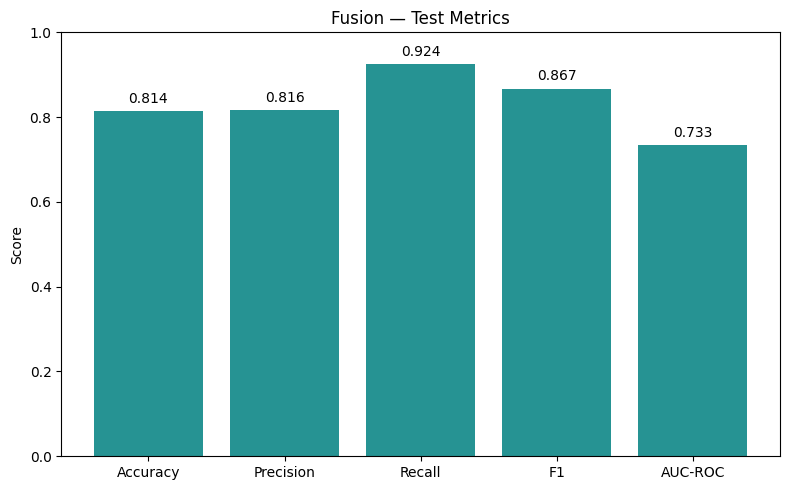

In [10]:
if fusion_metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    m = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
    v = [fusion_metrics["accuracy"], fusion_metrics["precision"], fusion_metrics["recall"],
         fusion_metrics["f1"], fusion_metrics["auc_roc"]]
    bars = ax.bar(m, v, color="teal", alpha=0.85)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title("Fusion — Test Metrics")
    for bar, val in zip(bars, v):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.3f}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()

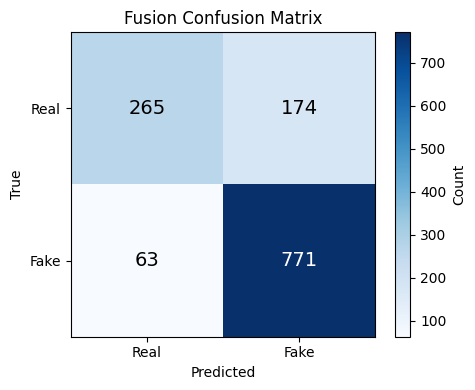

In [11]:
if fusion_metrics:
    cm = np.array(fusion_metrics["confusion_matrix"])
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Real", "Fake"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Real", "Fake"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Fusion Confusion Matrix")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
    plt.colorbar(im, ax=ax, label="Count")
    plt.tight_layout()
    plt.show()

## Overfitting

Train–val–test comparison. Large train–test gap = overfitting. Test AUC is the honest metric (unseen speakers).

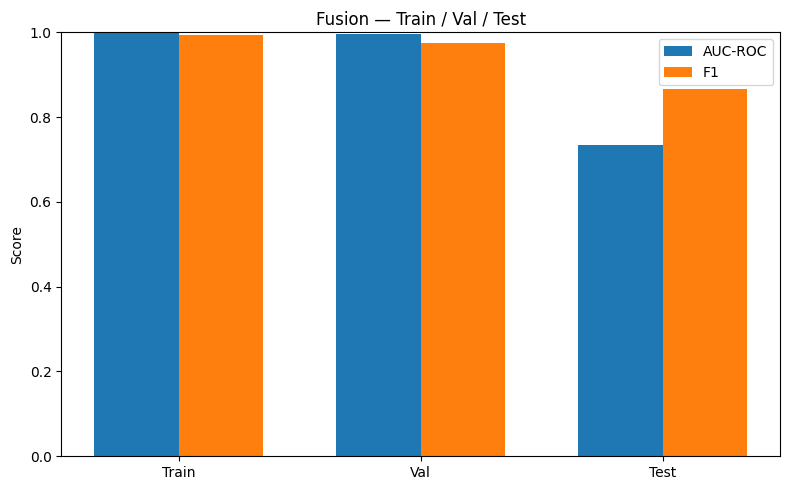

Train–Test AUC gap: 0.267


In [12]:
fusion_data = fusion_full
if fusion_data is None and ab_results:
    fusion_data = next((e for e in ab_results["experiments"] if "Fusion" in e["name"]), None)
if fusion_data:
    fig, ax = plt.subplots(figsize=(8, 5))
    splits = ["Train", "Val", "Test"]
    aucs = [fusion_data["train"]["auc_roc"], fusion_data["val"]["auc_roc"], fusion_data["test"]["auc_roc"]]
    f1s = [fusion_data["train"]["f1"], fusion_data["val"]["f1"], fusion_data["test"]["f1"]]
    x = np.arange(3)
    width = 0.35
    ax.bar(x - width/2, aucs, width, label="AUC-ROC")
    ax.bar(x + width/2, f1s, width, label="F1")
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title("Fusion — Train / Val / Test")
    ax.legend()
    plt.tight_layout()
    plt.show()
    gap = fusion_data["train"]["auc_roc"] - fusion_data["test"]["auc_roc"]
    print(f"Train–Test AUC gap: {gap:.3f}")

## Comparison: HF vs Acoustic vs Fusion

Uses controlled A/B results (`fusion_ab_results.json`) when available.

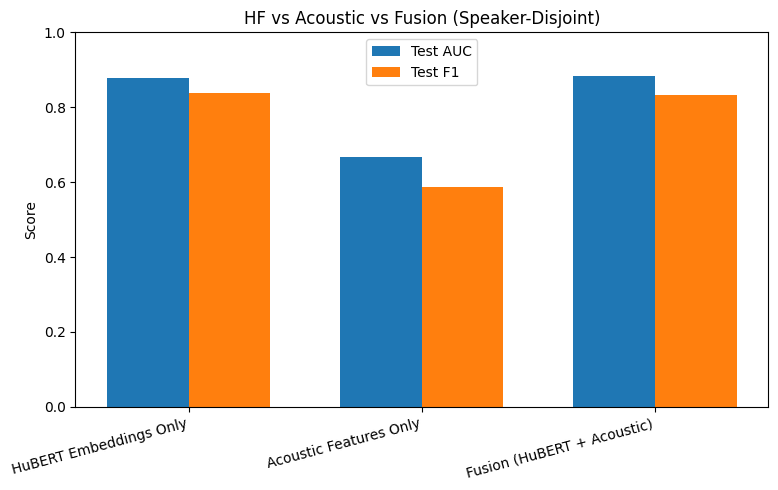

In [13]:
if ab_results:
    rows = ab_results["summary"]
    names = [r["Experiment"] for r in rows]
    aucs = [r["Test AUC"] for r in rows]
    f1s = [r["Test F1"] for r in rows]
elif fusion_metrics:
    comparison = [("Fusion", fusion_metrics["auc_roc"], fusion_metrics["f1"])]
    if (OUTPUTS_DIR / "transformer_results.json").exists():
        with open(OUTPUTS_DIR / "transformer_results.json") as f:
            tr = json.load(f)
        comparison.append(("Wav2Vec2", tr["wav2vec2"]["auc_roc"], tr["wav2vec2"]["f1"]))
    if (OUTPUTS_DIR / "baseline_results.json").exists():
        with open(OUTPUTS_DIR / "baseline_results.json") as f:
            bl = json.load(f)
        if "random_forest" in bl:
            comparison.append(("RF Acoustic", bl["random_forest"]["auc_roc"], bl["random_forest"]["f1"]))
    names, aucs, f1s = zip(*comparison)
else:
    names = aucs = f1s = []

if names:
    x = np.arange(len(names))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, aucs, width, label="Test AUC")
    ax.bar(x + width/2, f1s, width, label="Test F1")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title("HF vs Acoustic vs Fusion (Speaker-Disjoint)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Fusion Value

- **Fusion > HF:** Acoustic features add orthogonal signal → keep fusion
- **Fusion ≈ HF:** Transformer already encodes acoustic info → fusion marginal
- **Fusion < HF:** Acoustic features add noise → drop fusion

In [14]:
if ab_results:
    a = ab_results["analysis"]
    print(f"Test AUC: HF={a['test_auc_hf']:.4f}  Acoustic={a['test_auc_acoustic']:.4f}  Fusion={a['test_auc_fusion']:.4f}")
    print(f"Fusion − HF: {a['fusion_minus_hf']:+.4f} (|Δ| > 0.01 = meaningful)")
    print(f"\n{a['conclusion']}")
elif fusion_metrics and (OUTPUTS_DIR / "transformer_results.json").exists():
    with open(OUTPUTS_DIR / "transformer_results.json") as f:
        tr = json.load(f)
    delta = fusion_metrics["auc_roc"] - tr["wav2vec2"]["auc_roc"]
    print(f"Fusion vs Wav2Vec2: ΔAUC={delta:+.3f}")
    print("Run experiment_fusion_ab.py for controlled comparison.")

Test AUC: HF=0.8783  Acoustic=0.6662  Fusion=0.8840
Fusion − HF: +0.0057 (|Δ| > 0.01 = meaningful)

Fusion ≈ HuBERT. Transformer likely encodes most acoustic info. FUSION MARGINAL.
